# 04 — RQ2: aspect-based sentiment

**RQ2.** Which product aspects do reviewers discuss, and how does sentiment toward each aspect differ between the two categories?

A review-level label cannot capture this: one review can praise the content and slate the price. So RQ2 works **below the review**, at the sentence level, and is **unsupervised** — there are no aspect-level gold labels, so no supervised per-aspect classifier is possible.

**Method.**
1. Split each review into sentences.
2. Detect aspects per sentence with a curated keyword lexicon (plus a data-driven noun-phrase view).
3. Score each aspect-mentioning sentence with **VADER**, a lexicon-based sentiment scorer.

**Why VADER and not the RQ1 classifier?** The RQ1 model is trained on *whole reviews*; applying it to single *sentences* is out-of-distribution (sentences are far shorter, with a different feature distribution). VADER needs no training and is designed for short text, so it is the primary scorer. The RQ1 classifier is kept only as a **robustness check** (Section 6), and agreement between the two is reported rather than either being assumed correct.

In [1]:
import sys
from pathlib import Path

# Resolve project root whether launched from the repo root or notebooks/.
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
RANDOM_STATE = 42

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'
MODELS_DIR = PROJECT_ROOT / 'models'
for d in (PROC_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

NAVY, BLUE, ORANGE = '#1E3A6E', '#5B8DBF', '#D97757'

In [2]:
from src import dataset, aspect_extraction as ax
CATS = ['Subscription_Boxes', 'Magazine_Subscriptions']

df = pd.read_parquet(PROC_DIR / 'reviews_clean.parquet')
print(f'{len(df):,} reviews')

87,713 reviews


## 1. The aspect lexicon

Five conventional aspects plus two the EDA motivated: **content** (the core of a subscription) and **billing** (cancel/refund/charged — the negative-word cluster the log-odds analysis surfaced).

In [3]:
for aspect, kws in ax.DEFAULT_ASPECT_KEYWORDS.items():
    print(f'{aspect:18s} {kws}')

delivery           ['delivery', 'deliver', 'shipping', 'shipped', 'arrived', 'arrive', 'delayed', 'late', 'fast', 'shipment', 'courier']
packaging          ['packaging', 'package', 'packaged', 'box', 'wrapped', 'damaged', 'sealed', 'broken', 'crushed']
quality            ['quality', 'build', 'material', 'durable', 'cheap', 'sturdy', 'flimsy', 'well made', 'poorly made']
price              ['price', 'priced', 'value', 'expensive', 'overpriced', 'worth', 'affordable', 'cost', 'pricey']
content            ['content', 'selection', 'variety', 'curated', 'curation', 'items', 'products', 'magazine', 'issue', 'article', 'articles']
customer_service   ['service', 'support', 'response', 'helpful', 'rude', 'representative', 'contacted', 'email']
billing            ['cancel', 'cancelled', 'cancellation', 'refund', 'refunded', 'charged', 'charge', 'billing', 'subscription', 'renew', 'renewal', 'auto']


## 2. How attribution works — one worked example

This also exposes the method's main limitation up front.

In [4]:
example = "The curated selection was wonderful, but shipping was painfully slow and it felt overpriced."
print('Sentences:', ax.split_into_sentences(example))
ax.aspect_sentiment_vader(example)

Sentences: ['The curated selection was wonderful, but shipping was painfully slow and it felt overpriced.']


{'delivery': {'compound': -0.5023, 'label': 'negative', 'n_sentences': 1},
 'price': {'compound': -0.5023, 'label': 'negative', 'n_sentences': 1},
 'content': {'compound': -0.5023, 'label': 'negative', 'n_sentences': 1}}

**Reading — and a stated limitation.** When a single sentence mentions several aspects with *mixed* sentiment ("wonderful … but … overpriced"), VADER scores the whole sentence once and every aspect in it inherits that one compound value. Sentence-level attribution therefore cannot separate aspects that co-occur inside one sentence. This is acceptable here because reviews are short (median ~22 words, so most sentences carry one aspect), but it is a real boundary of the method. The natural refinement — splitting sentences into clauses on coordinating conjunctions before scoring — is noted as future work.

## 3. Corpus-level aspect-sentiment table

One row per (review, mentioned aspect). The cached table is loaded if present; otherwise it is built (~30-40s).

In [5]:
long_path = PROC_DIR / 'aspect_sentiment_long.parquet'
if long_path.exists():
    long_df = pd.read_parquet(long_path)
    print('loaded cached aspect table')
else:
    long_df = ax.build_aspect_sentiment_table(df['text'], df['category'], batch_size=2000)
    long_df.to_parquet(long_path, index=False)
    print('built and cached aspect table')
print(f'{len(long_df):,} aspect-rows | aspects: {sorted(long_df["aspect"].unique())}')
long_df.head()

built and cached aspect table
108,165 aspect-rows | aspects: ['billing', 'content', 'customer_service', 'delivery', 'packaging', 'price', 'quality']


,review_idx,category,aspect,compound,label,n_sentences
0,0,Subscription_Boxes,content,-0.2755,negative,1
1,1,Subscription_Boxes,content,-0.2912,negative,1
2,1,Subscription_Boxes,packaging,-0.2960,negative,1
3,1,Subscription_Boxes,quality,-0.2960,negative,1
4,7,Subscription_Boxes,content,0.5994,positive,1


## 4. Aggregate by category

In [6]:
nrev = df['category'].value_counts().to_dict()
agg = ax.aggregate_by_category(long_df, nrev)
agg.to_csv(TABLES_DIR / 'rq2_aspect_summary.csv')
agg

mention_count  mean_compound  \
category               aspect                                           
Magazine_Subscriptions billing                   14251         0.1736   
                       content                   45394         0.3706   
                       customer_service           3566         0.2937   
                       delivery                   5994         0.2282   
                       packaging                   924         0.2285   
                       price                      8983         0.3757   
                       quality                    3483         0.2918   
Subscription_Boxes     billing                    3948         0.1845   
                       content                    4683         0.3409   
                       customer_service            833         0.2814   
                       delivery                   2042         0.2346   
                       packaging                  7541         0.3108   
                       price                      3912         0.3016   
                       quality                    2611         0.3057   

                                         pct_positive  pct_neutral  \
category               aspect                                        
Magazine_Subscriptions billing                 0.4969       0.2930   
                       content                 0.7594       0.1535   
                       customer_service        0.6629       0.1183   
                       delivery                0.5339       0.3238   
                       packaging               0.5855       0.2229   
                       price                   0.7431       0.1276   
                       quality                 0.6239       0.2452   
Subscription_Boxes     billing                 0.5261       0.1963   
                       content                 0.7104       0.1550   
                       customer_service        0.6423       0.1537   
                       delivery                0.5695       0.2360   
                       packaging               0.6986       0.1536   
                       price                   0.6835       0.1158   
                       quality                 0.6473       0.2026   

                                         pct_negative  mention_rate  
category               aspect                                        
Magazine_Subscriptions billing                 0.2100        0.1993  
                       content                 0.0870        0.6349  
                       customer_service        0.2187        0.0499  
                       delivery                0.1423        0.0838  
                       packaging               0.1916        0.0129  
                       price                   0.1294        0.1256  
                       quality                 0.1309        0.0487  
Subscription_Boxes     billing                 0.2776        0.2435  
                       content                 0.1345        0.2888  
                       customer_service        0.2041        0.0514  
                       delivery                0.1944        0.1259  
                       packaging               0.1479        0.4650  
                       price                   0.2007        0.2412  
                       quality                 0.1501        0.1610

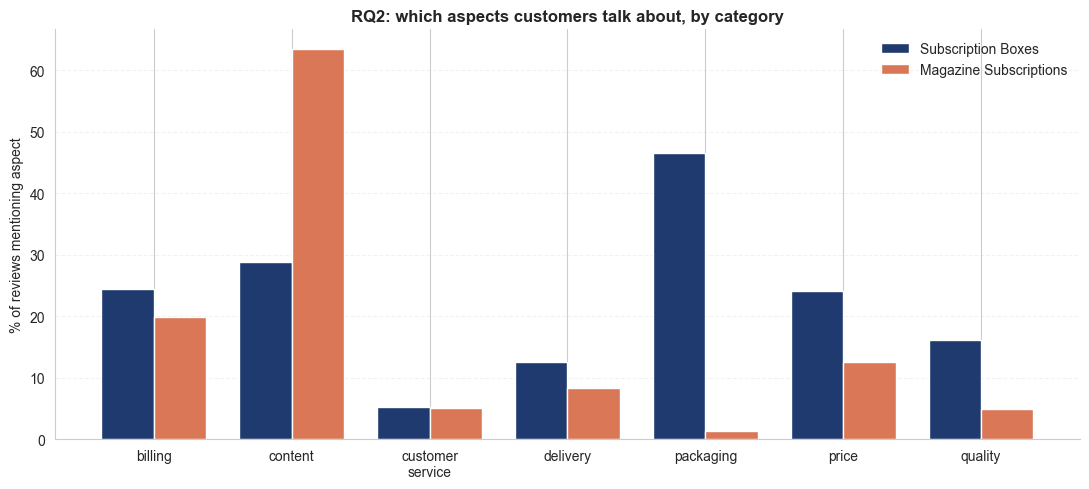

In [7]:
aspects = sorted(long_df['aspect'].unique())
x = np.arange(len(aspects)); w = 0.38

# mention rate
rate = agg['mention_rate'].unstack('category').reindex(aspects)
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(x - w/2, rate.get('Subscription_Boxes', 0) * 100, w, label='Subscription Boxes', color=NAVY)
ax1.bar(x + w/2, rate.get('Magazine_Subscriptions', 0) * 100, w, label='Magazine Subscriptions', color=ORANGE)
ax1.set_xticks(x); ax1.set_xticklabels([a.replace('_', '\n') for a in aspects])
ax1.set_ylabel('% of reviews mentioning aspect')
ax1.set_title('RQ2: which aspects customers talk about, by category', fontweight='bold')
ax1.legend(frameon=False); ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.25, ls='--'); ax1.set_axisbelow(True)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq2_mention_rate.png'); plt.show()

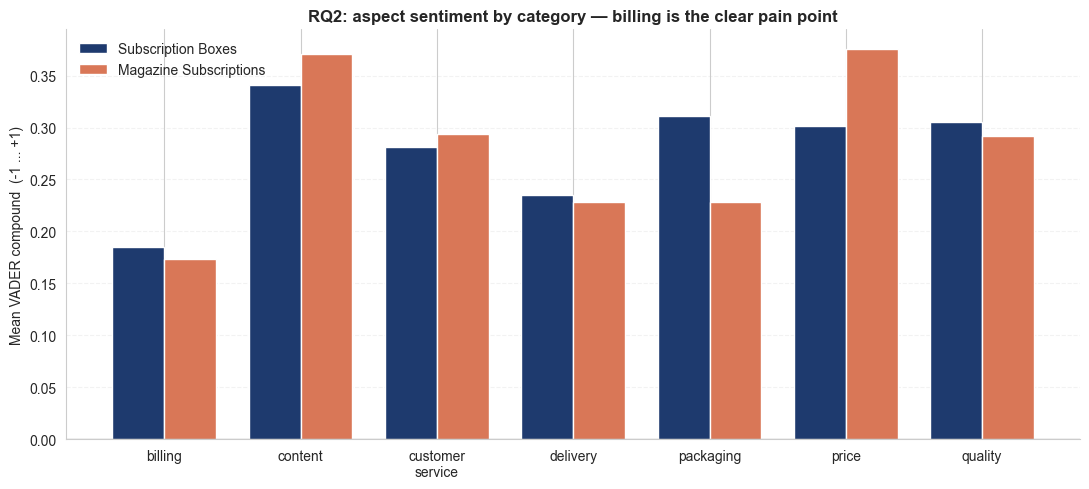

In [8]:
# mean sentiment
mc = agg['mean_compound'].unstack('category').reindex(aspects)
fig, ax2 = plt.subplots(figsize=(11, 5))
ax2.bar(x - w/2, mc.get('Subscription_Boxes', 0), w, label='Subscription Boxes', color=NAVY)
ax2.bar(x + w/2, mc.get('Magazine_Subscriptions', 0), w, label='Magazine Subscriptions', color=ORANGE)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x); ax2.set_xticklabels([a.replace('_', '\n') for a in aspects])
ax2.set_ylabel('Mean VADER compound  (-1 ... +1)')
ax2.set_title('RQ2: aspect sentiment by category — billing is the clear pain point', fontweight='bold')
ax2.legend(frameon=False); ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.25, ls='--'); ax2.set_axisbelow(True)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq2_aspect_sentiment.png'); plt.show()

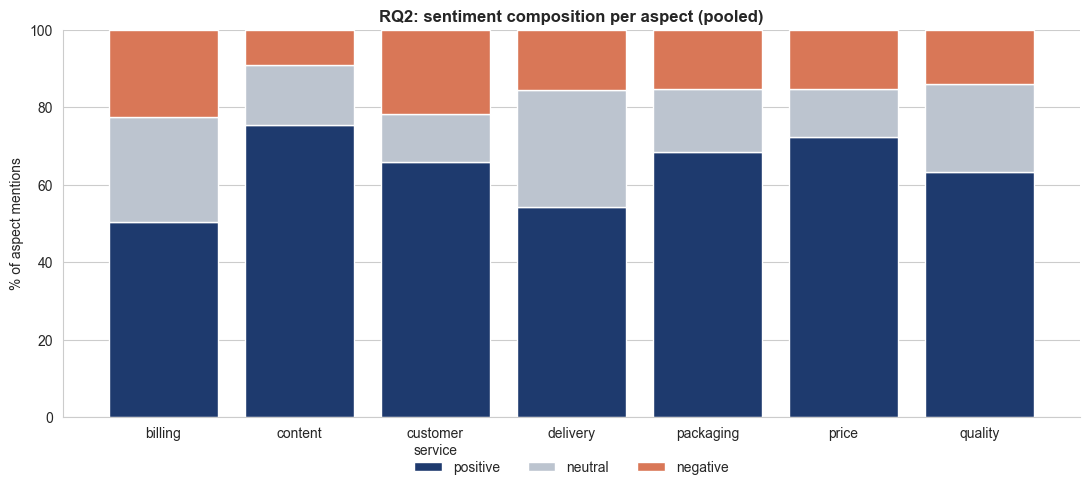

In [9]:
# sentiment composition (pooled)
pooled = long_df.groupby('aspect')['label'].value_counts(normalize=True).unstack(fill_value=0).reindex(aspects)
fig, ax3 = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(aspects))
for lbl, color in [('positive', NAVY), ('neutral', '#BCC4CF'), ('negative', ORANGE)]:
    vals = pooled.get(lbl, pd.Series(0, index=aspects)).values * 100
    ax3.bar(aspects, vals, bottom=bottom, label=lbl, color=color); bottom += vals
ax3.set_xticklabels([a.replace('_', '\n') for a in aspects]); ax3.set_ylim(0, 100)
ax3.set_ylabel('% of aspect mentions')
ax3.set_title('RQ2: sentiment composition per aspect (pooled)', fontweight='bold')
ax3.legend(frameon=False, ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.18))
ax3.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq2_sentiment_composition.png'); plt.show()

**Reading.** Two clear patterns. **What people talk about differs by category**: Magazine reviews are dominated by *content* (~63% of reviews mention it), while Subscription-Box reviews talk far more about *packaging* (~47%) — the physical unboxing matters for boxes, the editorial substance for magazines. **What people complain about is shared**: in both categories *billing* has by far the lowest mean sentiment and the highest negative share (~21-28% negative), while *content* and *price* skew most positive. The billing signal echoes RQ1's strongest negative coefficient (*cancel*) — the same pain point seen from two methods.

## 5. Noun-phrase analysis (data-driven aspect candidates)

A complementary, lexicon-free view: the most frequent noun phrases per category, on a sample for tractability.

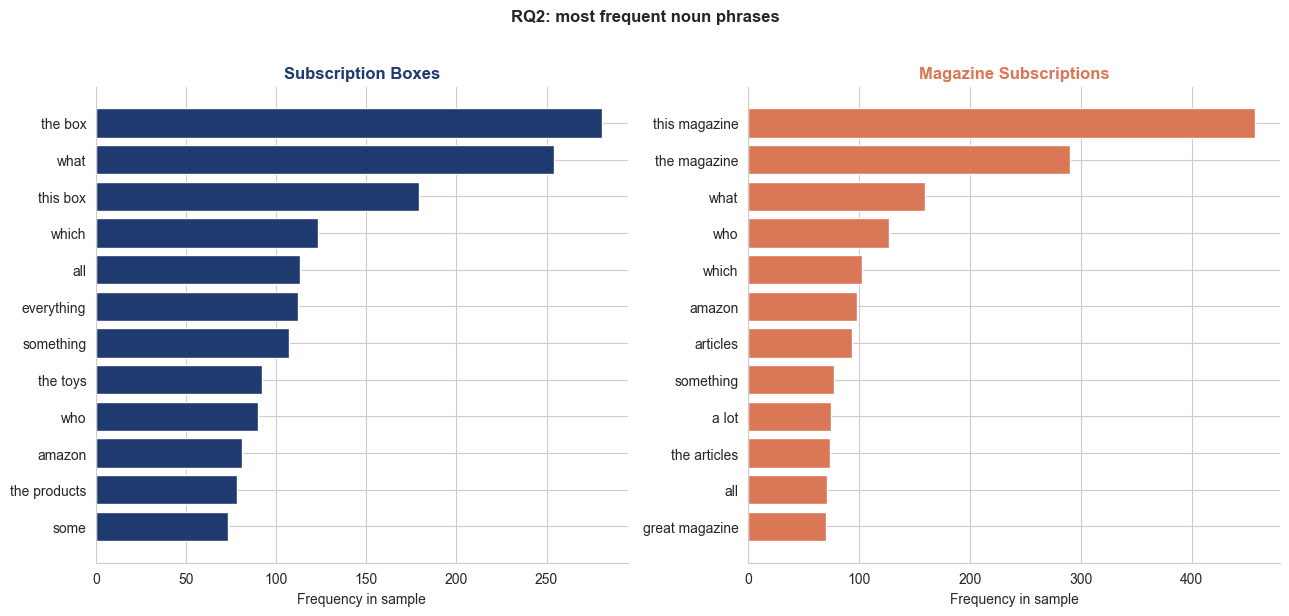

,noun_phrase,count
0,the box,281
1,what,254
2,this box,179
3,which,123
4,all,113
5,everything,112
6,something,107
7,the toys,92
8,who,90
9,amazon,81


In [10]:
np_tables = {}
for cat in CATS:
    texts = df[df['category'] == cat]['text'].dropna()
    texts = texts.sample(min(2000, len(texts)), random_state=42)
    np_tables[cat] = pd.DataFrame(ax.top_noun_phrases(texts, n=20), columns=['noun_phrase', 'count'])
    np_tables[cat].to_csv(TABLES_DIR / f'rq2_top_noun_phrases_{cat}.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for axx, cat, color in zip(axes, CATS, [NAVY, ORANGE]):
    t = np_tables[cat].head(12).iloc[::-1]
    axx.barh(t['noun_phrase'], t['count'], color=color)
    axx.set_title(cat.replace('_', ' '), fontweight='bold', color=color)
    axx.set_xlabel('Frequency in sample'); axx.spines[['top', 'right']].set_visible(False)
plt.suptitle('RQ2: most frequent noun phrases', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq2_noun_phrases.png'); plt.show()
np_tables['Subscription_Boxes'].head(10)

**Reading.** The frequent noun phrases independently validate the keyword lexicon: *the box / the toys / the products / the price / the items* for boxes, *this magazine / the articles / subscription* for magazines all map onto the predefined aspects (content, price, packaging). One data-quality note: a stray `br` token appears for magazines — a leftover from `<br>` HTML tags in the raw text, which the noun-phrase view uses unmodified. It does not affect the keyword/VADER pipeline, which scores cleaned aspect sentences.

## 6. Robustness check — VADER vs the RQ1 classifier

How far does the document-trained classifier drift when pushed down to single sentences? The classifier is binary (positive/negative), so agreement is measured on the non-neutral subset where a fair comparison exists.

In [11]:
import pickle
lr = pickle.load(open(MODELS_DIR / 'lr_binary.pkl', 'rb'))
vec = pickle.load(open(MODELS_DIR / 'tfidf_binary.pkl', 'rb'))
dfc = df[df['clean_text'].str.len() > 0].copy()
_, test_df = dataset.chronological_split(dfc, by_category=True)
sample = test_df.sample(min(1500, len(test_df)), random_state=7)

comp = ax.compare_vader_vs_classifier(sample['text'].tolist(), lr, vec)
non_neutral = comp[comp['vader_label'] != 'neutral']
overall = non_neutral['agree'].mean()
per_aspect = (non_neutral.groupby('aspect')['agree'].agg(['mean', 'size'])
              .rename(columns={'mean': 'agreement', 'size': 'n'}).round(3))
per_aspect.to_csv(TABLES_DIR / 'rq2_vader_vs_classifier_agreement.csv')
print(f'Overall agreement on non-neutral aspect mentions: {overall:.1%} (n={len(non_neutral)})')
print(f'VADER labels {(comp["vader_label"] == "neutral").mean():.1%} of mentions neutral '
      f'(the binary classifier cannot express this).')
per_aspect

Overall agreement on non-neutral aspect mentions: 75.0% (n=1308)
VADER labels 23.0% of mentions neutral (the binary classifier cannot express this).


,agreement,n
aspect,,
billing,0.690,203
content,0.803,639
customer_service,0.679,56
delivery,0.602,83
packaging,0.737,114
price,0.730,137
quality,0.737,76


**Reading.** The two methods agree on roughly three quarters of non-neutral aspect mentions — close enough to confirm VADER is not producing nonsense, divergent enough to matter. Crucially, VADER labels ~22% of aspect mentions *neutral*, a category the binary classifier structurally cannot produce. Combined with the out-of-distribution concern (the classifier was trained on whole reviews), this justifies using **VADER as the primary sentence-level scorer** and the classifier only as a sanity check.

**RQ2 takeaways.**
- Working at the sentence level recovers per-aspect sentiment that a review-level label cannot represent — the gap RQ1 flagged.
- *What* is discussed is category-specific (content for magazines, packaging for boxes); *what frustrates* customers is shared and concentrated in **billing**.
- The billing finding is corroborated by RQ1's most negative model coefficient — two independent methods, one conclusion.
- **Limitations:** sentence-level scoring cannot separate multiple aspects inside one sentence; the lexicon is hand-built and English-only; VADER is general-purpose, not domain-tuned. Clause-level splitting and a domain-adapted lexicon are the natural next steps.